# Evolución de la matriz energética de México

## Introducción

En este proyecto se analiza la evolución de la matriz energética de México utilizando datos de **Our World in Data**.

Se estudia la proporción de energía proveniente de fuentes limpias respecto al consumo energético total y se ajustan diferentes funciones matemáticas para describir su evolución temporal.

## Objetivo

Analizar la evolución de la proporción de energía limpia en México y encontrar una función que represente adecuadamente su trayectoria, para utilizarla como referencia en la construcción de la función techo de mitigación `miuup` del modelo DICE.

## Librerías

Se importan las principales librerías utilizadas para la manipulación de datos, visualización y ajuste de las funciones.

- **Pandas:** manejo y análisis de datos.
- **NumPy:** operaciones numéricas.
- **Matplotlib:** visualización de los datos y resultados.
- **SciPy:** ajuste de funciones mediante `curve_fit`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Carga de datos

Se carga el archivo `owid-energy-data.csv` en un DataFrame de Pandas. Posteriormente, se muestran las primeras filas para verificar la estructura y el contenido inicial del conjunto de datos.

In [2]:
df_global = pd.read_csv("owid-energy-data.csv")
df_global.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


### Rango temporal

Se identifica el primer y último año disponible en el conjunto de datos para conocer el periodo cubierto por la información.

In [4]:
year_min = df_global["year"].min()
year_max = df_global["year"].max()

print("Datos desde" ,year_min)
print("hasta", year_max)

Datos desde 1900
hasta 2025


### Selección y limpieza de los datos

Se seleccionan los datos correspondientes a México a partir del año 2000. Se eliminan los registros que no cuentan con información sobre la generación total de electricidad.

Finalmente, se conservan únicamente las variables necesarias para el análisis: generación total y generación eléctrica proveniente de fuentes hidroeléctricas, nucleares, solares, eólicas y otras fuentes renovables.

In [5]:
df_mx = df_global[(df_global["country"] == "Mexico") & (df_global["year"] >= 2000)].copy()

# Eliminar filas donde M_MX o la generación total sea NaN
df_mx = df_mx.dropna(subset=['electricity_generation'])

cols_interes = ['year', 
    'electricity_generation',  # Generación Total
    'hydro_electricity', 
    'nuclear_electricity', 
    'solar_electricity', 
    'wind_electricity', 
    'other_renewable_electricity']

df_mx = df_mx[cols_interes]

df_mx.head()

,year,electricity_generation,hydro_electricity,nuclear_electricity,solar_electricity,wind_electricity,other_renewable_electricity
12423,2000,203.619995,33.070000,8.22,0.01,0.02,6.36
12424,2001,210.220001,28.440001,8.73,0.01,0.02,6.25
12425,2002,215.729996,24.860001,9.75,0.01,0.02,6.07
12426,2003,224.899994,19.850000,10.50,0.01,0.02,6.95
12427,2004,235.389999,25.180000,9.19,0.01,0.02,7.26


### Construcción de la fracción de energía limpia

Se calcula la generación eléctrica limpia como la suma de la generación proveniente de fuentes hidroeléctricas, nucleares, solares, eólicas y otras fuentes renovables.

A partir de esta cantidad se define la fracción de generación limpia respecto a la generación eléctrica total:

$$
M_{MX} =
\frac{\text{Generación limpia}}
{\text{Generación eléctrica total}}
$$

Esta fracción, $M_{MX}$, será la variable utilizada para analizar la evolución de la participación de fuentes limpias en la generación eléctrica de México.

In [6]:
# Suma total de generación limpia
df_mx['generacion_limpia_twh'] = (
    df_mx['hydro_electricity'] +
    df_mx['nuclear_electricity'] +
    df_mx['solar_electricity'] +
    df_mx['wind_electricity'] +
    df_mx['other_renewable_electricity']
)

# Fracción M_MX = Generación Limpia / Generación Total
df_mx['M_MX'] = df_mx['generacion_limpia_twh'] / df_mx['electricity_generation']

# Renombramos columnas para claridad
df_mx = df_mx.rename(columns={'electricity_generation': 'generacion_total_twh'})

## Evolución de la generación limpia

Se visualiza la evolución de la fracción de generación eléctrica limpia en México a lo largo del periodo analizado. Cada punto representa el valor de $M_{MX}$ correspondiente a un año.

Esta primera visualización permite observar la tendencia de los datos antes de realizar los ajustes matemáticos.

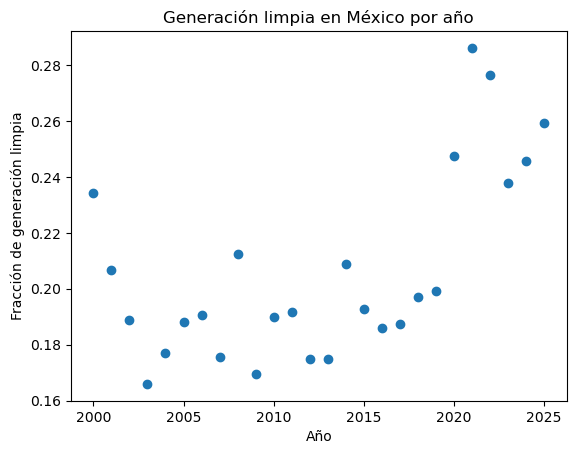

In [9]:
plt.plot(df_mx["year"],df_mx["M_MX"],'o')
plt.xlabel("Año")
plt.ylabel("Fracción de generación limpia")
plt.title("Generación limpia en México por año")
plt.show()

## Escala temporal y dominio de proyección

Para hacer compatible los datos históricos con la escala temporal utilizada en DICE, se transforma el año calendario a una variable $t$, tomando 2020 como $t=0$ y utilizando intervalos de cinco años:

$$
t = \frac{\text{año} - 2020}{5}.
$$

Los datos históricos se mantienen desde el año 2000 y se utilizan posteriormente para realizar los ajustes.

Para visualizar las funciones ajustadas, se define un dominio continuo entre 2000 y 2060. De esta manera, las trayectorias pueden compararse con la totalidad de los datos históricos y extenderse posteriormente hacia el periodo de proyección.

Finalmente, se calcula la suma total de cuadrados de los datos históricos, que será utilizada para calcular el coeficiente de determinación $R^2$ de los distintos ajustes.

In [11]:
#DATOS HISTÓRICOS Y ESCALA DE TIEMPO (DICE: t = 0 en 2020, paso de 5 años)
años_reales = df_mx["year"].values
fraccion_real = df_mx["M_MX"].values
# t_datos = (años_reales - 2020) / 5.0
t_datos = (años_reales - 2020) / 5.0

# Dominio de proyección (2005 - 2060)
años_proy = np.linspace(2000, 2060, 300)
t_proy = (años_proy - 2020) / 5.0

# Suma total de cuadrados para el cálculo de R²
ss_tot = np.sum((fraccion_real - np.mean(fraccion_real)) ** 2)

## Modelos matemáticos

Se definen siete modelos candidatos para representar la evolución de la fracción de generación limpia $M_{MX}$ en función del tiempo.

Se consideran modelos polinomiales de primer, segundo y tercer grado, así como tres funciones de crecimiento sigmoidal y una función logística:

- **Lineal:** representa una tasa de cambio constante.
- **Cuadrático:** permite representar una tasa de cambio que varía con el tiempo.
- **Cúbico:** proporciona mayor flexibilidad para representar cambios en la curvatura.
- **Logístico:** representa un crecimiento sigmoidal con un límite superior.
- **Gompertz:** representa un crecimiento sigmoidal asimétrico.
- **Sigmoidal acotada:** establece un límite superior fijo en $1$.
- **Sigmoidal libre:** permite que el límite superior sea determinado por el ajuste.

Estas funciones se compararán posteriormente para determinar cuáles describen mejor la tendencia observada en los datos históricos.

In [14]:
# DEFINICIÓN DE LOS 7 MODELOS
def mod_lineal(t, b, c):
    return b * t + c

def mod_cuadratico(t, a, b, c):
    return a * (t**2) + b * t + c

def mod_cubico(t, d, a, b, c):
    return d * (t**3) + a * (t**2) + b * t + c

def mod_logistica(t, L, k, t0):
    return L / (1.0 + np.exp(-k * (t - t0)))

def mod_gompertz(t, L, c, k):
    return L * np.exp(-c * np.exp(-k * t))

def mod_sigmoide_t1(t, k, t0, M0):
    return M0 + (1.0 - M0) / (1.0 + np.exp(-k * (t - t0)))

def mod_sigmoide_libre(t, L, k, t0, M0):
    return M0 + (L - M0) / (1.0 + np.exp(-k * (t - t0)))

## Ajuste de parámetros y evaluación

Cada uno de los siete modelos se ajusta a los datos históricos mediante `curve_fit`, que determina los valores de los parámetros que minimizan la diferencia entre el modelo y los datos observados.

Para comparar el desempeño de los modelos se calcula el coeficiente de determinación $R^2$:

$$
R^2 =
1-\frac{\sum_i (y_i-\hat{y}_i)^2}
{\sum_i (y_i-\bar{y})^2}.
$$

donde $y_i$ representa los valores observados, $\hat{y}_i$ los valores estimados por el modelo y $\bar{y}$ la media de los datos.

Un valor de $R^2$ cercano a $1$ indica que el modelo reproduce una mayor proporción de la variabilidad observada en los datos.

Para los modelos sigmoidal, logístico y Gompertz se establecen valores iniciales (`p0`) y límites (`bounds`) para los parámetros con el fin de orientar el ajuste hacia regiones físicamente razonables y evitar soluciones no deseadas.

In [15]:
# AJUSTE DE PARÁMETROS Y CÁLCULO DE R²
# 1. Lineal
popt_lin, _ = curve_fit(mod_lineal, t_datos, fraccion_real)
r2_lin = 1 - (np.sum((fraccion_real - mod_lineal(t_datos, *popt_lin))**2) / ss_tot)

# 2. Cuadrática
popt_quad, _ = curve_fit(mod_cuadratico, t_datos, fraccion_real)
r2_quad = 1 - (np.sum((fraccion_real - mod_cuadratico(t_datos, *popt_quad))**2) / ss_tot)

# 3. Cúbica
popt_cub, _ = curve_fit(mod_cubico, t_datos, fraccion_real)
r2_cub = 1 - (np.sum((fraccion_real - mod_cubico(t_datos, *popt_cub))**2) / ss_tot)

# 4. Logística Libre
popt_log, _ = curve_fit(mod_logistica, t_datos, fraccion_real, p0=[0.40, 0.2, 0.0], bounds=([0.25, 0.01, -10.0], [0.80, 2.0, 10.0]), maxfev=5000)
r2_log = 1 - (np.sum((fraccion_real - mod_logistica(t_datos, *popt_log))**2) / ss_tot)

# 5. Gompertz Libre
popt_gomp, _ = curve_fit(mod_gompertz, t_datos, fraccion_real, p0=[0.40, 1.0, 0.1], bounds=([0.25, 0.1, 0.001], [0.80, 5.0, 1.0]), maxfev=5000)
r2_gomp = 1 - (np.sum((fraccion_real - mod_gompertz(t_datos, *popt_gomp))**2) / ss_tot)

# 6. Sigmoide Techo L=1.0 (Resto Libre)
popt_sig1, _ = curve_fit(mod_sigmoide_t1, t_datos, fraccion_real, p0=[0.2, 0.0, 0.17], bounds=([0.001, -20.0, 0.10], [5.0, 50.0, 0.22]), maxfev=10000)
r2_sig1 = 1 - (np.sum((fraccion_real - mod_sigmoide_t1(t_datos, *popt_sig1))**2) / ss_tot)

# 7. Sigmoide Completamente Libre
popt_sig_lib, _ = curve_fit(mod_sigmoide_libre, t_datos, fraccion_real, p0=[0.35, 0.5, 0.0, 0.17], bounds=([0.25, 0.01, -5.0, 0.10], [0.50, 3.0, 5.0, 0.20]), maxfev=5000)
r2_sig_lib = 1 - (np.sum((fraccion_real - mod_sigmoide_libre(t_datos, *popt_sig_lib))**2) / ss_tot)

## Resultados de los ajustes

Se muestran los valores de $R^2$ y los parámetros obtenidos para cada uno de los siete modelos.

Esta comparación permite identificar las funciones que presentan un mejor ajuste a los datos históricos y analizar posteriormente sus diferencias en la trayectoria proyectada.

In [16]:
# IMPRESIÓN DE RESULTADOS EN CONSOLA
print("================================================================================")
print("                       RESUMEN DE AJUSTES Y PARÁMETROS                          ")
print("================================================================================")
print(f"1. Lineal              | R² = {r2_lin:.4f} | Parámetros [b, c]: {np.round(popt_lin, 5)}")
print(f"2. Cuadrática          | R² = {r2_quad:.4f} | Parámetros [a, b, c]: {np.round(popt_quad, 5)}")
print(f"3. Cúbica              | R² = {r2_cub:.4f} | Parámetros [d, a, b, c]: {np.round(popt_cub, 5)}")
print(f"4. Logística           | R² = {r2_log:.4f} | Parámetros [L, k, t0]: {np.round(popt_log, 5)}")
print(f"5. Gompertz            | R² = {r2_gomp:.4f} | Parámetros [L, c, k]: {np.round(popt_gomp, 5)}")
print(f"6. Sigmoide (L=1.0)    | R² = {r2_sig1:.4f} | Parámetros [k, t0, M0]: {np.round(popt_sig1, 5)}")
print(f"7. Sigmoide COMP. LIBRE| R² = {r2_sig_lib:.4f} | Parámetros [L, k, t0, M0]: {np.round(popt_sig_lib, 5)}")
print("================================================================================")

                       RESUMEN DE AJUSTES Y PARÁMETROS                          
1. Lineal              | R² = 0.3575 | Parámetros [b, c]: [0.01316 0.22606]
2. Cuadrática          | R² = 0.6600 | Parámetros [a, b, c]: [0.00905 0.0403  0.22606]
3. Cúbica              | R² = 0.6732 | Parámetros [d, a, b, c]: [-0.00144  0.00256  0.0364   0.22993]
4. Logística           | R² = 0.3764 | Parámetros [L, k, t0]: [ 0.79708  0.09192 10.     ]
5. Gompertz            | R² = 0.3651 | Parámetros [L, c, k]: [0.8     1.26212 0.0482 ]
6. Sigmoide (L=1.0)    | R² = 0.5661 | Parámetros [k, t0, M0]: [0.92155 3.25761 0.18471]
7. Sigmoide COMP. LIBRE| R² = 0.6763 | Parámetros [L, k, t0, M0]: [ 0.2669   3.      -0.11528  0.18768]


## Comparación de los ajustes

Se comparan en una misma gráfica los datos históricos y las trayectorias obtenidas mediante los siete modelos.

Los puntos representan los valores observados de $M_{MX}$, mientras que las curvas muestran los valores estimados por cada función en el intervalo 2000–2060.

La línea vertical en 2020 identifica el año base utilizado para la escala temporal de DICE, mientras que la línea horizontal en $M_{MX}=1$ representa una participación del 100% de generación limpia.

La comparación permite evaluar no solo el ajuste de cada función a los datos históricos, sino también el comportamiento de las distintas trayectorias al extenderse hacia el periodo futuro.

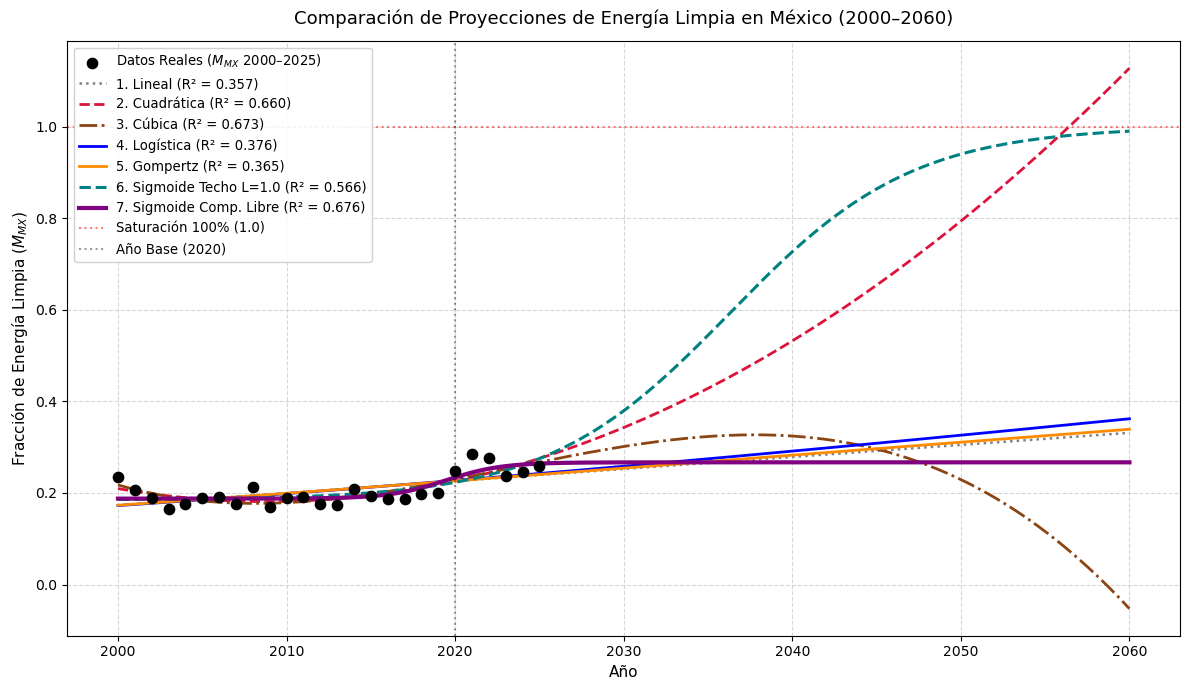

In [18]:
# VISUALIZACIÓN UNIFICADA (HASTA 2060)
plt.figure(figsize=(12, 7))

# Datos Reales
plt.scatter(años_reales, fraccion_real, color='black', s=55, zorder=10, label='Datos Reales ($M_{MX}$ 2000–2025)')

# Curvas de Proyección
plt.plot(años_proy, mod_lineal(t_proy, *popt_lin), color='gray', linestyle=':', linewidth=1.8, label=f'1. Lineal (R² = {r2_lin:.3f})')
plt.plot(años_proy, mod_cuadratico(t_proy, *popt_quad), color='crimson', linestyle='--', linewidth=2, label=f'2. Cuadrática (R² = {r2_quad:.3f})')
plt.plot(años_proy, mod_cubico(t_proy, *popt_cub), color='saddlebrown', linestyle='-.', linewidth=2, label=f'3. Cúbica (R² = {r2_cub:.3f})')
plt.plot(años_proy, mod_logistica(t_proy, *popt_log), color='blue', linewidth=2, label=f'4. Logística (R² = {r2_log:.3f})')
plt.plot(años_proy, mod_gompertz(t_proy, *popt_gomp), color='darkorange', linewidth=2, label=f'5. Gompertz (R² = {r2_gomp:.3f})')
plt.plot(años_proy, mod_sigmoide_t1(t_proy, *popt_sig1), color='teal', linestyle='--', linewidth=2.2, label=f'6. Sigmoide Techo L=1.0 (R² = {r2_sig1:.3f})')
plt.plot(años_proy, mod_sigmoide_libre(t_proy, *popt_sig_lib), color='purple', linewidth=3, label=f'7. Sigmoide Comp. Libre (R² = {r2_sig_lib:.3f})')

# Referencias
plt.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='Saturación 100% (1.0)')
plt.axvline(x=2020, color='black', linestyle=':', alpha=0.4, label='Año Base (2020)')

plt.title('Comparación de Proyecciones de Energía Limpia en México (2000–2060)', fontsize=13, pad=12)
plt.xlabel('Año', fontsize=11)
plt.ylabel('Fracción de Energía Limpia ($M_{MX}$)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=9.5, framealpha=0.9)
plt.tight_layout()
plt.show()

## Análisis de resultados

Los valores de $R^2$ permiten identificar cuatro modelos con un desempeño superior al resto: cuadrático ($R^2=0.6600$), cúbico ($R^2=0.6732$), sigmoide con techo en $L=1$ ($R^2=0.5661$) y sigmoide completamente libre ($R^2=0.6763$). 

Estos resultados muestran que las funciones con mayor flexibilidad para representar la curvatura de los datos presentan, en general, un mejor ajuste. Sin embargo, el valor de $R^2$ se utiliza únicamente como una primera referencia para evaluar el ajuste histórico. La selección final de la trayectoria también considera el comportamiento de las funciones fuera del periodo observado y su interpretación como fracción de generación limpia.

### Comportamiento de las trayectorias

El modelo cúbico presenta un $R^2$ ligeramente superior al cuadrático. Sin embargo, al extender la función fuera del periodo histórico, la trayectoria comienza a decrecer y alcanza valores negativos antes de 2050. Debido a que $M_{MX}$ representa una fracción de generación limpia, estos valores no tienen una interpretación física válida. Por esta razón, el modelo cúbico se descarta a pesar de presentar un mejor $R^2$ que el modelo cuadrático.

Las dos trayectorias sigmoides presentan comportamientos contrastantes. La sigmoide con techo fijo en $L=1$ representa la trayectoria más optimista, ya que continúa creciendo hasta alcanzar el 100% de generación limpia. En contraste, la sigmoide completamente libre converge hacia un valor cercano a $0.27$, representando la trayectoria más conservadora de las alternativas consideradas.

La trayectoria cuadrática presenta un comportamiento intermedio entre ambas. Su crecimiento es más gradual que el de la sigmoide con techo en $1$, pero continúa aumentando hasta alcanzar la saturación del 100%.

## Selección de la trayectoria

La selección de la trayectoria no se realiza únicamente con base en el valor de $R^2$. Aunque el modelo cúbico y la sigmoide completamente libre presentan valores ligeramente superiores al cuadrático, su comportamiento proyectado resulta menos adecuado para el objetivo del análisis.

La función cúbica se descarta debido a que su extrapolación produce valores negativos antes de 2050. Por otro lado, la sigmoide completamente libre converge hacia aproximadamente $0.27$, lo que representa una trayectoria muy conservadora. En el extremo opuesto, la sigmoide con techo en $1$ representa una trayectoria más optimista, al aproximarse progresivamente al 100% de generación limpia.

Se selecciona el **modelo cuadrático** como una alternativa intermedia entre estos escenarios. Esta función presenta un buen ajuste a los datos históricos y una trayectoria de crecimiento gradual, evitando tanto el comportamiento no físico del modelo cúbico como la fuerte saturación de la sigmoide libre.

Finalmente, para mantener la interpretación de $M_{MX}$ como una fracción acotada entre $0$ y $1$, la trayectoria cuadrática se trunca al alcanzar $M_{MX}=1$. A partir de ese punto se establece:

$$
M_{MX}=1.
$$

De esta manera, la trayectoria seleccionada combina un ajuste adecuado a los datos históricos con un comportamiento de proyección consistente con los límites de la variable.